# F10 · El selector: S0 contra S1

**Qué pregunta responde.** Si el selector propio es aportación o adorno, y si sigue
aportando cuando el prompt ya lleva clics de fondo.

**S1 está reformulado y la reformulación es un resultado** (apartado 5.5): la guarda
anti-núcleo cayó por la misma cadena que M2, y con ella `FRAC_MAX`, el único parámetro
libre del criterio. Lo que queda (contener el clic 0, no contener negativos, ordenar por z
contra el fondo local, desempatar por elongación) **no tiene umbrales que calibrar**.

**Qué hay que haber corrido antes**, todo en `surco`, porque reordenar candidatas ya
calculadas es aritmética y **no vuelve a ejecutar ningún modelo**:

```
conda run -n surco python scripts/selector_s0_s1.py
conda run -n surco python scripts/selector_clasico.py
conda run -n surco python scripts/diagnostico_z.py
```

Necesitan los `.npz` de `salidas/proceso/candidatas/` que dejó F8. Este notebook corre en
**`surco`**.

**M4 es la excepción y por eso no sale aquí sino en F8.** En M0 y M1 el selector se puede
aplicar después sobre las candidatas guardadas, porque no cambia lo que el modelo ve en el
frame siguiente. En M4 sí lo cambia: la máscara que se reencadena es la que eligió el
selector, así que M4 × S0 y M4 × S1 son dos cadenas distintas y hay que correr las dos
dentro del entorno del modelo.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))  # los scripts agregan; el notebook solo muestra

from surco import config, figuras, metricas
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from surco import figuras
from tabla_selector import degenerados, descomposicion, dejando_una_serie_fuera, por_celda, por_protocolo

# proceso/selector.csv <- scripts/selector_s0_s1.py (entorno surco), que lee los
# proceso/candidatas/*.npz que dejo scripts/profundidad.py en F8
tabla = pd.read_csv(config.DIR_PROCESO / "selector.csv")
sin_eleccion = degenerados(tabla)
vivas = tabla[~tabla["modelo"].isin(sin_eleccion)]
print(f"celda degenerada, una sola candidata: {', '.join(sin_eleccion)} (fuera de los agregados)")
celdas = por_celda(vivas)

celda degenerada, una sola candidata: sammed2d (fuera de los agregados)


In [2]:
separadas = celdas[(celdas["ic_bajo"] > 0) | (celdas["ic_alto"] < 0)]
print(f"celdas cuyo intervalo no cruza el cero: {len(separadas)} de {len(celdas)}")
print(separadas.to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

celdas cuyo intervalo no cruza el cero: 8 de 24
     modelo modo protocolo  dice_s0  dice_s1  s1_menos_s0  ic_bajo  ic_alto  ganadas  coincide  respaldo
microsam_lm   M0        P2   0.1850   0.1146      -0.0704  -0.1185  -0.0254        5    0.1831    0.1831
microsam_lm   M1        P3   0.3821   0.4184       0.0364   0.0099   0.0656        9    0.2949    0.0000
microsam_lm   M1        P4   0.4429   0.5264       0.0835   0.0371   0.1339       12    0.2576    0.0881
      sam21   M1        P2   0.2313   0.2975       0.0662   0.0370   0.0976       15    0.3661    0.0780
      sam21   M1        P3   0.2392   0.3386       0.0994   0.0367   0.1644       13    0.4000    0.0034
      sam21   M1        P4   0.3305   0.4785       0.1480   0.0998   0.1955       17    0.2983    0.2576
    tinysam   M1        P3   0.2451   0.3106       0.0654   0.0156   0.1153       10    0.2712    0.0000
    tinysam   M1        P4   0.3444   0.4117       0.0673   0.0233   0.1079       15    0.3017    0.4576


In [3]:
print("¿Sigue aportando con clics de fondo?")
print(por_protocolo(celdas).to_string(float_format=lambda v: f"{v:7.4f}"))
print("\nLas dos mitades de S1 por separado, contra S0:")
print(descomposicion(vivas).to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

¿Sigue aportando con clics de fondo?
           celdas  s1_menos_s0  coincide  respaldo
protocolo                                         
P1              6      -0.0020    0.3932    0.0000
P2              6       0.0007    0.3073    0.0644
P3              6       0.0433    0.3407    0.0006
P4              6       0.0696    0.2927    0.2435

Las dos mitades de S1 por separado, contra S0:
protocolo  respaldo      s1              s1_ic  puerta          puerta_ic  ranking         ranking_ic
       P1    0.0000 -0.0020 [-0.0266, +0.0229] -0.0011 [-0.0052, +0.0018]   0.0021 [-0.0256, +0.0308]
       P2    0.0644  0.0007 [-0.0288, +0.0316]  0.0207 [-0.0037, +0.0463]  -0.0110 [-0.0347, +0.0115]
       P3    0.0006  0.0433 [+0.0102, +0.0805] -0.0041 [-0.0077, -0.0013]   0.0546 [+0.0189, +0.0936]
       P4    0.2435  0.0696 [+0.0396, +0.1000]  0.0516 [+0.0325, +0.0711]   0.0459 [+0.0138, +0.0808]


In [4]:
print("Dejando una serie fuera (no calibra: S1 no tiene umbrales)")
print(dejando_una_serie_fuera(vivas).to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

clasico = pd.read_csv(config.DIR_PROCESO / "selector_clasico.csv")  # <- selector_clasico.py
print("\nEl mismo S1 sobre el filtro de cresta: ¿es el selector o es SAM?")
for protocolo, grupo in clasico.groupby("protocolo"):
    medias = {c: metricas.media_entre_unidades(metricas.por_unidad(grupo, c))
              for c in ("dice_una", "dice_s0", "dice_s1")}
    print(f"  {protocolo}  una {medias['dice_una']:.4f}  S0 {medias['dice_s0']:.4f}  S1 {medias['dice_s1']:.4f}")

Dejando una serie fuera (no calibra: S1 no tiene umbrales)
 serie_fuera  unidades  s1_menos_s0  ganadas
           1         2       0.0733        2
           2         2       0.0419        2
           3         1       0.0432        1
           4         2      -0.0026        1
           5         3      -0.0004        1
           6         1       0.0782        1
           7         2      -0.0531        0
           9         2       0.0432        2
          10         2       0.0743        2

El mismo S1 sobre el filtro de cresta: ¿es el selector o es SAM?
  P1  una 0.1715  S0 0.3064  S1 0.3040
  P2  una 0.1630  S0 0.2726  S1 0.2712
  P3  una 0.4165  S0 0.3999  S1 0.4312
  P4  una 0.4020  S0 0.3403  S1 0.3822


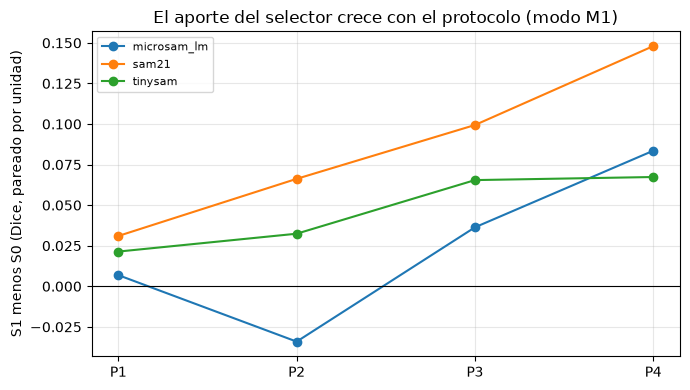

In [5]:
figura, ejes = plt.subplots(figsize=(7, 4))
for modelo, grupo in celdas[celdas["modo"] == "M1"].groupby("modelo"):
    ejes.plot(grupo["protocolo"], grupo["s1_menos_s0"], marker="o", label=modelo)
ejes.axhline(0, color="black", lw=0.8)
ejes.set_ylabel("S1 menos S0 (Dice, pareado por unidad)")
ejes.set_title("El aporte del selector crece con el protocolo (modo M1)")
ejes.legend(fontsize=8)
ejes.grid(alpha=0.3)
figura.tight_layout()
figuras.guardar(figura, "figura_f10_selector.png")

In [6]:
# Overlays: la mejor celda del trabajo, sea cual sea. El titulo y el nombre del
# fichero salen de config.MEJOR_CELDA en vez de escribirse a mano, que es como
# los overlays acabaron dibujando M1 x P4 x S1 despues de que M4 subiera el techo.
celda = config.MEJOR_CELDA
etiqueta = f"{celda['modo']} × {celda['protocolo']} × {celda['selector']}"
pares = figuras.pares_de_figura()
figura = figuras.rejilla_de_overlays(
    pares, figuras.mascara_del_mejor_modelo,
    f"micro-sam LM {celda['checkpoint']} · {etiqueta} · relleno = predicción, contorno = GT",
    f"overlay_microsam_{celda['modo']}_{celda['protocolo']}_{celda['selector']}.png".lower(),
)